## Allen helper example

In [2]:
import sys
sys.path.append('..')

from allen_functions import AllenHelper

Instantiate helper for Atlas ID 3 (refer docs/Data.md for a table of allowed IDs and their meaning)

In [3]:
helper = AllenHelper(atlas_id=3, downsample=3)

In [4]:
# helper.images

In [6]:
AllenHelper?

Init signature: AllenHelper(atlas_id: int = 3, downsample: int = 3)
Docstring:     
Helper for uniform access to Allen image and annotation data, compatible 
with dharani_functions.py
Init docstring:
Args:
    atlas_id : [3, 287730656, 138322603]

        mpp = 2^downsample
    downsample = 3 [default] => mpp=8 ; allowed [0..7]

atlas ids:
* 3 = 21 pcw cerebrum [default]
* 287730656 = 21 pcw brainstem
* 138322603 = 15 pcw
File:           c:\users\keerthi\code\hbp\sgbc_dharani_data_tutorial\dharani_data_tutorial\allen_functions.py
Type:           type
Subclasses:     

In [7]:
sectionlist = helper.get_section_numbers()

In [5]:
im_arr = helper.get_sectionimage(357)

In [6]:
im_arr.shape

(4756, 2452, 3)

In [78]:
helper.get_section_urls(357)

('http://api.brain-map.org/api/v2/atlas_image_download/101892528?downsample=3&annotation=false&atlas=3',
 'http://api.brain-map.org/api/v2/svg/101892528?downsample=3&groups=31')

In [7]:
helper.get_viewer_url(357)

'https://atlas.brain-map.org/atlas?atlas=3&plate=101892528&zoom=-5'

In [8]:
annot357 = helper.get_annotation(357)

### Allen ontology helper

In [9]:
from ontology_handling import TreeHelper
ontohelper_allen = TreeHelper('allen_devhuman')

In [10]:
TreeHelper?

Init signature: TreeHelper(ontoname='dharani')
Docstring:      Abstracts ontology tree reading, searching and navigation for Dharani and Allen nomenclature
Init docstring: ontoname: ['dharani', 'allen_devhuman'] 
File:           c:\users\keerthi\code\hbp\sgbc_dharani_data_tutorial\dharani_data_tutorial\ontology_handling.py
Type:           type
Subclasses:     

In [11]:
len(ontohelper_allen)

3315

In [1]:
# ontohelper_allen.print_tree()

### display annotations

In [13]:
from nb_functions import display_annotation, display_annotation_tree

function `display_annotation` shows the available regions in `annot` as a tab-indented list with color legend

There are two plots in the end, the left shows the image, and the right shows all the annotations (by default)

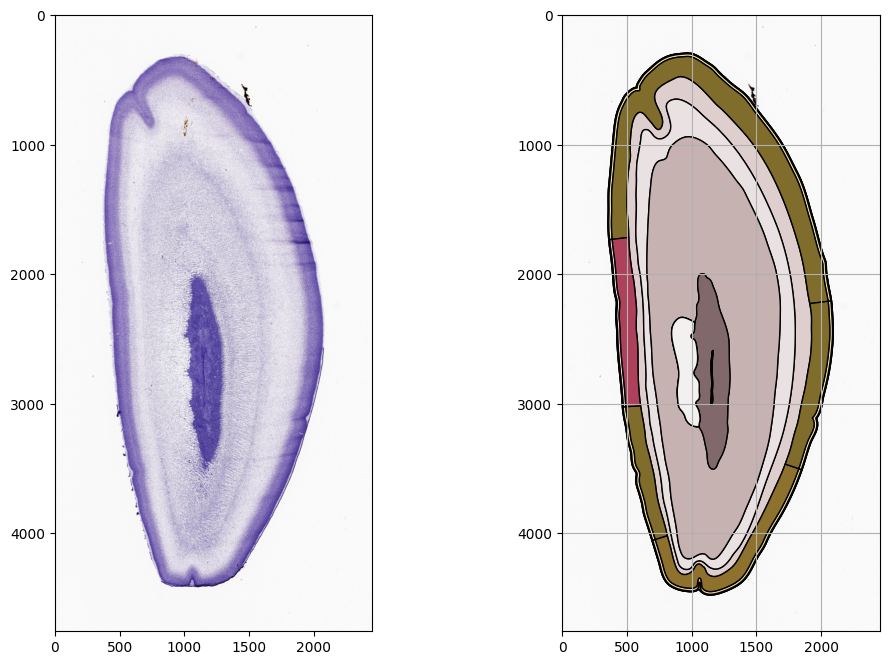

In [15]:
displayedids,superannot=display_annotation(im_arr, annot357, ontohelper_allen)

The return value `displayedids` has a list of ontology ids that were displayed in the second plot. The return value `superannot` is a dictionary of inferred annotations (by default, there was no request for inferences, and so should be empty)

We see that various levels in the ontology are annotated, with overlapping annotations

a filter for ``selectedlev`` is provided in the display function. 

### exercise 1

Lets pass `selectedlev` = 3

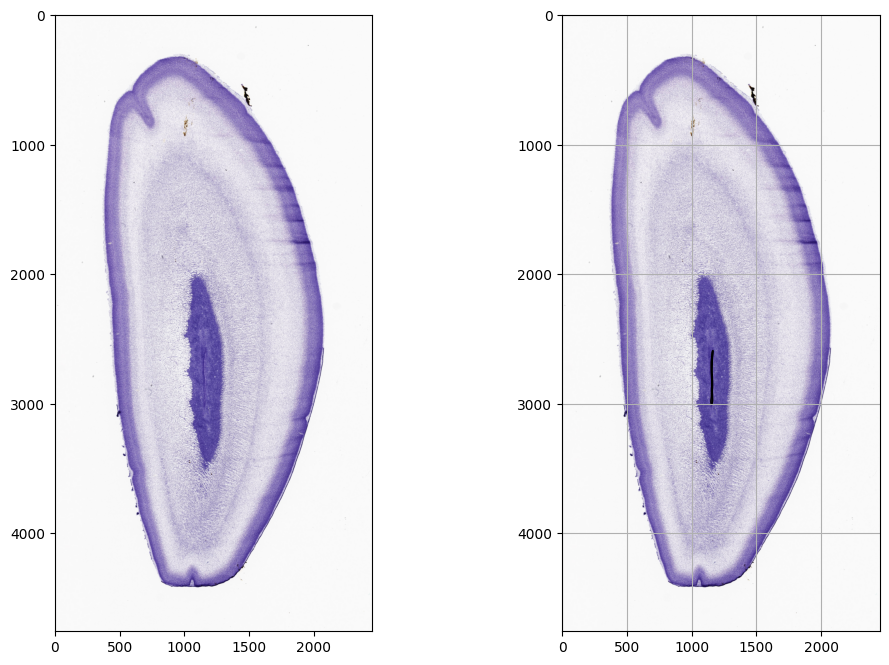

In [19]:
displayedids, superannot = display_annotation(im_arr, annot357, ontohelper_allen, selectedlev=3)

In [20]:
displayedids

[10596]

In [21]:
superannot

{}

although more ids are printed, only one (explicitly annotated) got displayed. Also, no inferences yet.

The function can also take a list `ontoids` which will infer the supershapes from `annot` and display as a third image

### exercise 2

sending a single value in `ontoids`

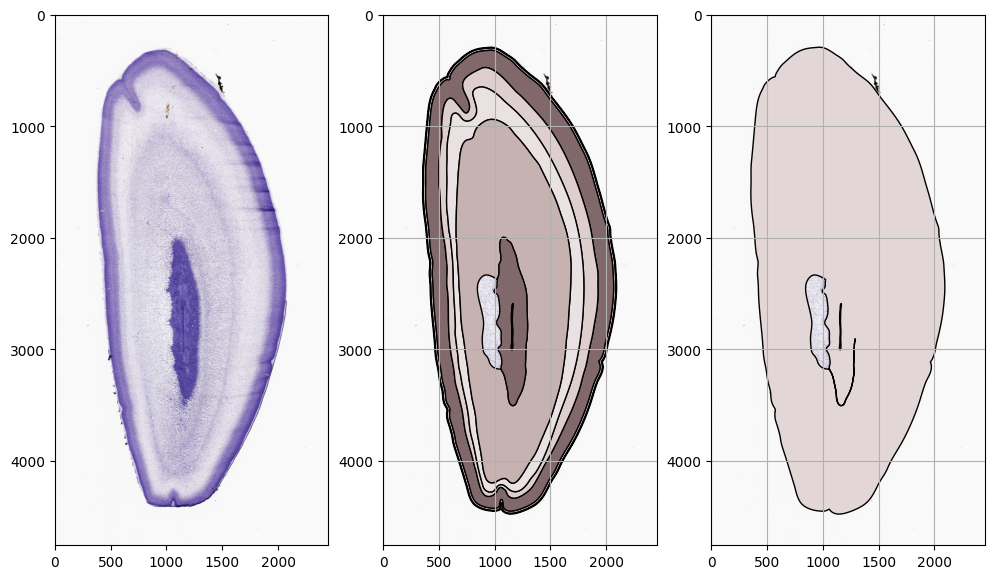

In [24]:
displayedids,superannot = display_annotation(im_arr,annot357, ontohelper_allen, selectedlev=3, ontoids=[10506])

In [25]:
displayedids

[10508, 10515, 10522, 10529, 10536, 10542, 10596, 11580]

In [26]:
superannot

{10506: <POLYGON ((2083.542 2241.096, 2083.493 2240.582, 2083.368 2239.016, 2082.841...>}

The id `10506` was inferred, by taking its 7 children that were annotated. This is seen in the indication (+7) in the tree listing.

The color used for the inferred region is as per the ontology

### exercise 3

A deeper level, without any ontoids (similar to exercise 1)

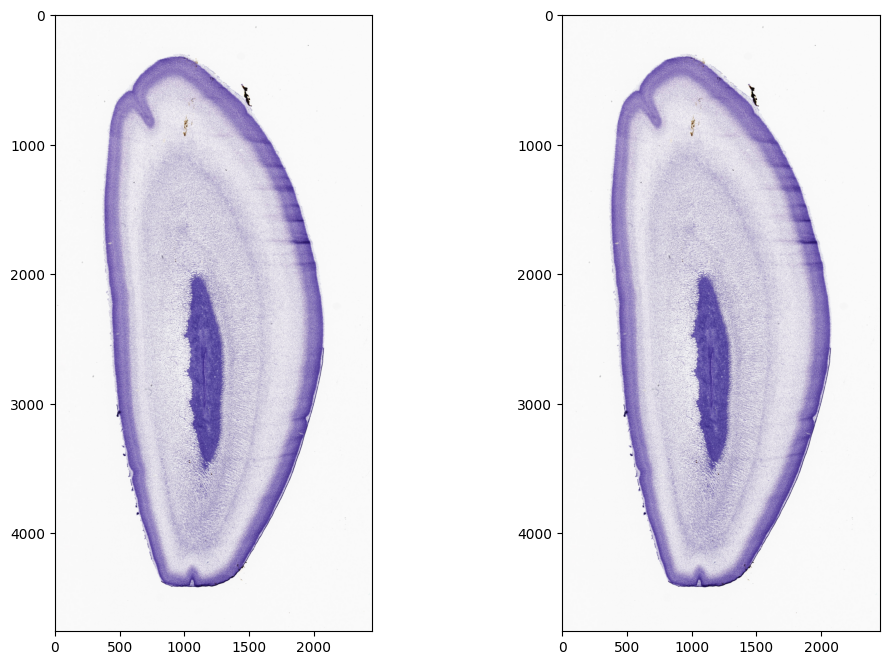

In [27]:
displayedids, superannot = display_annotation(im_arr,annot357, ontohelper_allen, selectedlev=5)

In [28]:
displayedids

[]

In [29]:
superannot

{}

Nothing was displayed, though the tree listing showed some inferrable parents (prefixed with (+NNN))

### exercise 4

Specifying some of the parents, to request them to be inferred and displayed. The tree display should expand at the requested ids, and the third column of plot should reflect the request

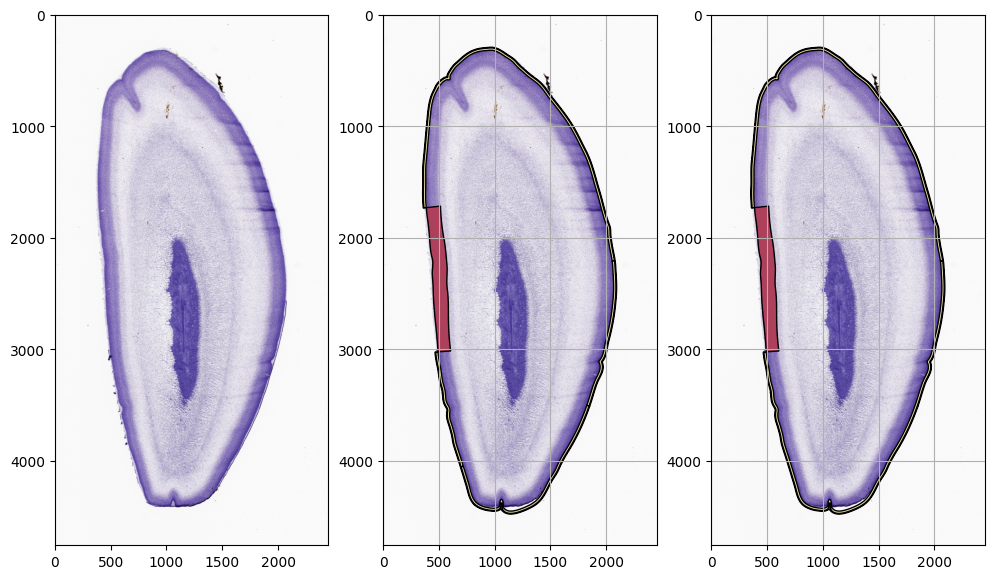

In [37]:
displayedids, superannot = display_annotation(im_arr,annot357, ontohelper_allen, selectedlev=5, ontoids=[ 11581, 11715, 10509])

In [38]:
displayedids

[11583, 11585, 11586, 11587, 11608, 11610, 11611, 11612, 11716]

In [39]:
superannot

{11581: <MULTIPOLYGON (((2087.624 2310.22, 2087.624 2310.211, 2087.623 2310.203, 208...>,
 11715: <POLYGON ((412.478 1956.716, 414.399 1977.809, 416.009 1998.942, 417.456 202...>,
 10509: <MULTIPOLYGON (((2080.924 2298.781, 2080.569 2292.823, 2080.217 2286.839, 20...>}